In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)

y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [3]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)

y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

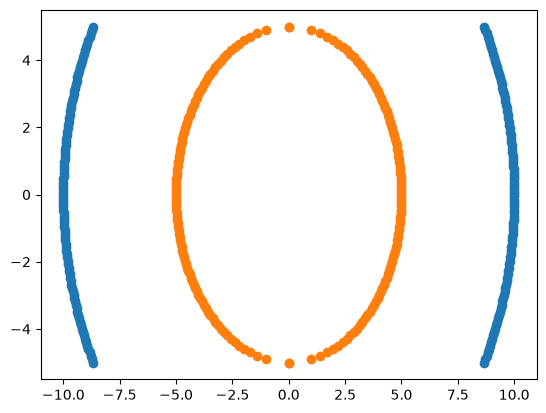

In [4]:
plt.scatter(y, x)
plt.scatter(y1, x1)

In [5]:
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=["X1", "X2"])
df1["Y"] = 0
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=["X1", "X2"])
df2["Y"] = 1

df = pd.concat([df1, df2])

In [6]:
df

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0
...,...,...,...
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1


In [7]:
X = df.iloc[:, :2]
y = df["Y"]

In [8]:
X

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596
...,...,...
195,-1.969049,-4.59596
196,-1.714198,-4.69697
197,-1.406908,-4.79798
198,-0.999949,-4.89899


In [9]:
y

0      0
1      0
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Y, Length: 400, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [11]:
df["X1_Square"] = df["X1"]**2
df["X2_Square"] = df["X2"]**2
df["X1*X2"] = df["X1"]*df["X2"]

In [12]:
df

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009
...,...,...,...,...,...,...
195,-1.969049,-4.59596,1,3.877155,21.122845,9.049671
196,-1.714198,-4.69697,1,2.938476,22.061524,8.051537
197,-1.406908,-4.79798,1,1.979390,23.020610,6.750316
198,-0.999949,-4.89899,1,0.999898,24.000102,4.898740


In [13]:
X = df.drop(columns=["Y"])
y = df["Y"]

In [14]:
X

,X1,X2,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,78.877155,21.122845,-40.818009
...,...,...,...,...,...
195,-1.969049,-4.59596,3.877155,21.122845,9.049671
196,-1.714198,-4.69697,2.938476,22.061524,8.051537
197,-1.406908,-4.79798,1.979390,23.020610,6.750316
198,-0.999949,-4.89899,0.999898,24.000102,4.898740


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [16]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
47,4.993619,-0.252525,24.936231,0.063769,-1.261015
110,-9.169553,3.989899,84.080706,15.919294,-36.585591
16,9.410082,-3.383838,88.549638,11.450362,-31.842196
66,9.860133,1.666667,97.222222,2.777778,16.433555
153,-9.993749,-0.353535,99.875013,0.124987,3.533143
...,...,...,...,...,...
71,9.761334,2.171717,95.283645,4.716355,21.198857
106,-8.982945,4.393939,80.693297,19.306703,-39.470515
70,4.551063,2.070707,20.712172,4.287828,9.423918
148,-4.997704,0.151515,24.977043,0.022957,-0.757228


In [17]:
y_train

47     1
110    0
16     0
66     0
153    0
      ..
71     0
106    0
70     1
148    1
102    0
Name: Y, Length: 300, dtype: int64

In [18]:
import plotly.express as px

fig = px.scatter_3d(df, x="X1", y="X2", z="X1*X2", color="Y")
fig.show(renderer="iframe")

In [19]:
fig = px.scatter_3d(df, x="X1_Square", y="X2_Square", z="X1*X2", color="Y")
fig.show(renderer="iframe")

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))

1.0
